UPLOAD PJME_hourly.csv


Saving PJME_hourly.csv to PJME_hourly (1).csv

Training LightGBM Model...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004765 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1366
[LightGBM] [Info] Number of data points in the train set: 116158, number of used features: 10
[LightGBM] [Info] Start training from score 32327.191610
Training Complete!

Model Performance
------------------------------
Mean Absolute Error : 352.17 MW
Approximate Accuracy : 98.87%

Model saved as smart_grid.pkl


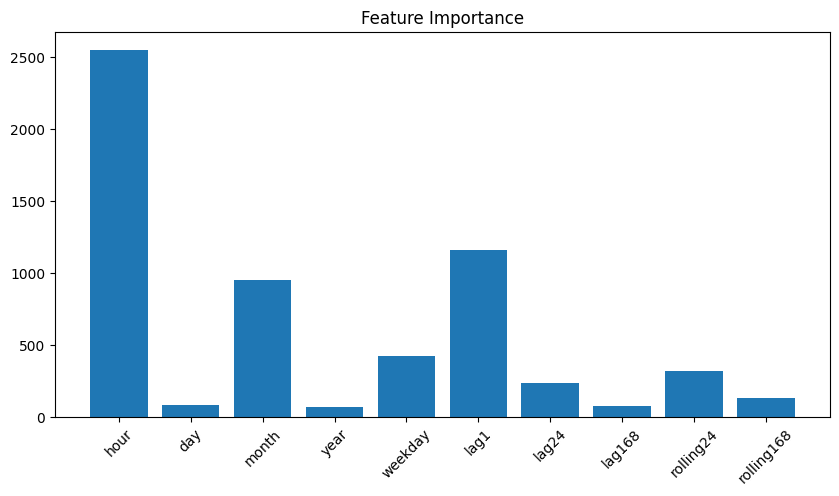

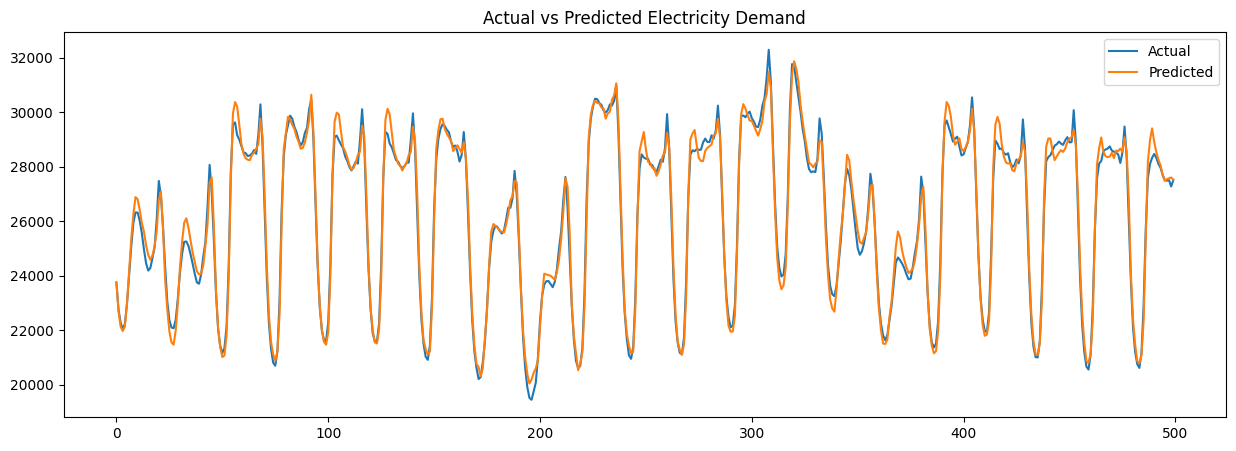


PROJECT IS READY!
Run the CLI cell now.


In [1]:
# ===========================
# SMART ENERGY GRID FORECASTING
# Complete Training Code
# ===========================

# Install libraries
!pip -q install lightgbm joblib

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import mean_absolute_error
from lightgbm import LGBMRegressor

from google.colab import files

print("="*60)
print("UPLOAD PJME_hourly.csv")
print("="*60)

uploaded = files.upload()

# Get uploaded filename automatically
filename = list(uploaded.keys())[0]

# -----------------------------
# Load Dataset
# -----------------------------
df = pd.read_csv(filename)

# Rename columns (if required)
if "Datetime" not in df.columns:
    df.columns = ["Datetime", "PJME_MW"]

# -----------------------------
# Datetime Processing
# -----------------------------
df["Datetime"] = pd.to_datetime(df["Datetime"])

df = df.sort_values("Datetime")

df.set_index("Datetime", inplace=True)

# -----------------------------
# Feature Engineering
# -----------------------------
df["hour"] = df.index.hour
df["day"] = df.index.day
df["month"] = df.index.month
df["year"] = df.index.year
df["weekday"] = df.index.weekday

# -----------------------------
# Lag Features
# -----------------------------
df["lag1"] = df["PJME_MW"].shift(1)
df["lag24"] = df["PJME_MW"].shift(24)
df["lag168"] = df["PJME_MW"].shift(168)

# -----------------------------
# Rolling Features
# -----------------------------
df["rolling24"] = df["PJME_MW"].rolling(24).mean()
df["rolling168"] = df["PJME_MW"].rolling(168).mean()

# Remove missing rows
df.dropna(inplace=True)

# -----------------------------
# Feature Selection
# -----------------------------
X = df.drop("PJME_MW", axis=1)
y = df["PJME_MW"]

# -----------------------------
# Train-Test Split
# -----------------------------
split = int(len(df) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

# -----------------------------
# Train Model
# -----------------------------
print("\nTraining LightGBM Model...")

model = LGBMRegressor(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

model.fit(X_train, y_train)

print("Training Complete!")

# -----------------------------
# Prediction
# -----------------------------
pred = model.predict(X_test)

# -----------------------------
# Evaluation
# -----------------------------
mae = mean_absolute_error(y_test, pred)

print("\nModel Performance")
print("-"*30)
print(f"Mean Absolute Error : {mae:.2f} MW")

accuracy = 100 - (mae / y_test.mean()) * 100
print(f"Approximate Accuracy : {accuracy:.2f}%")

# -----------------------------
# Save Model
# -----------------------------
joblib.dump(model, "smart_grid.pkl")

print("\nModel saved as smart_grid.pkl")

# -----------------------------
# Feature Importance
# -----------------------------
plt.figure(figsize=(10,5))
plt.bar(X.columns, model.feature_importances_)
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.show()

# -----------------------------
# Prediction Graph
# -----------------------------
plt.figure(figsize=(15,5))
plt.plot(y_test.values[:500], label="Actual")
plt.plot(pred[:500], label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Electricity Demand")
plt.show()

print("\n" + "="*60)
print("PROJECT IS READY!")
print("Run the CLI cell now.")
print("="*60)

In [2]:
import pandas as pd

print("=" * 65)
print("      SMART ENERGY GRID LOAD & PEAK FORECASTING SYSTEM")
print("=" * 65)

while True:

    print("\nEnter Forecast Date & Time")

    day = int(input("Day (1-31): "))
    month = int(input("Month (1-12): "))
    year = int(input("Year: "))
    hour = int(input("Time (Hour 0-23): "))

    try:
        # Create timestamp
        target_time = pd.Timestamp(
            year=year,
            month=month,
            day=day,
            hour=hour
        )

        # Check if timestamp exists
        if target_time not in df.index:
            print("\n❌ Date & Time not found in the dataset.")
            continue

        # Fetch the row
        row = df.loc[target_time]

        # Create input for the model
        sample = pd.DataFrame({
            'hour': [hour],
            'day': [day],
            'month': [month],
            'year': [year],
            'weekday': [target_time.weekday()],
            'lag1': [row['lag1']],
            'lag24': [row['lag24']],
            'lag168': [row['lag168']],
            'rolling24': [row['rolling24']],
            'rolling168': [row['rolling168']]
        })

        # Predict
        prediction = model.predict(sample)[0]

        print("\n" + "=" * 65)
        print("Forecast Summary")
        print("=" * 65)
        print(f"Date                : {day:02d}-{month:02d}-{year}")
        print(f"Time                : {hour:02d}:00")
        print(f"Weekday             : {target_time.day_name()}")
        print(f"Predicted Demand    : {prediction:.2f} MW")

        if prediction > 50000:
            print("Grid Status         : ⚠️ PEAK LOAD EXPECTED")
        else:
            print("Grid Status         : ✅ NORMAL LOAD")

        print("=" * 65)

    except Exception as e:
        print("\nError:", e)

    choice = input("\nDo you want to predict another time? (y/n): ")

    if choice.lower() != "y":
        print("\nThank you for using Smart Energy Grid Forecasting!")
        break

      SMART ENERGY GRID LOAD & PEAK FORECASTING SYSTEM

Enter Forecast Date & Time
Day (1-31): 5
Month (1-12): 10
Year: 2015
Time (Hour 0-23): 10

Forecast Summary
Date                : 05-10-2015
Time                : 10:00
Weekday             : Monday
Predicted Demand    : 29778.40 MW
Grid Status         : ✅ NORMAL LOAD

Do you want to predict another time? (y/n): y

Enter Forecast Date & Time
Day (1-31): 10
Month (1-12): 2
Year: 2008
Time (Hour 0-23): 20

Forecast Summary
Date                : 10-02-2008
Time                : 20:00
Weekday             : Sunday
Predicted Demand    : 38827.09 MW
Grid Status         : ✅ NORMAL LOAD

Do you want to predict another time? (y/n): n

Thank you for using Smart Energy Grid Forecasting!
